# Analisi e Visualizzazione dei Benchmark delle Metriche RAG

Questo notebook analizza le performance di retrieval delle fasi sperimentali caricate dal file JSON `data/metrics/raw_new_benchmarks.json`.

Vengono confrontati:
1. **I Parser in lingua Italiana** (`docling`, `pdf4llm`, `llamaparse`, `mineru`, `qwen`, `euristico`) combinati con le strategie di **Rerank** e **Graph**.
2. **Le Strategie di Retrieval in lingua Inglese** (`Vector`, `Hybrid`, `Rerank`, `Graph`) testate su diverse configurazioni di database.

In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione dello stile grafico (coerente con eval_llm.ipynb)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

In [2]:
# Caricamento dei dati grezzi dal file JSON
json_path = "../data/metrics/raw_new_benchmarks.json"

with open(json_path, "r", encoding="utf-8") as f:
    benchmarks_data = json.load(f)

print("Sezioni caricate dal file JSON:", list(benchmarks_data.keys()))

Sezioni caricate dal file JSON: ['rerank_local_it', 'graph_local_it', 'english_benchmark']


In [29]:
FIGSIZE = (20, 20)
TITLE_FONTSIZE = 25
LABEL_FONTSIZE = 20
LEGEND_FONTSIZE = 18
LEGEND_TITLE_FONTSIZE = 20
BAR_FONTSIZE = 18

## 1. Confronto dei Parser per l'Italiano (Rerank vs Graph)

Estraiamo i dati per la lingua italiana. Identifichiamo il parser a partire dal nome del database e ordiniamo i risultati in base a una gerarchia fissa di parser con `euristico` (la nostra baseline) in prima posizione.

In [3]:
it_records = []

def extract_parser_name(db_name):
    # Esempio: chroma_pdf4llm_locale_700 -> pdf4llm
    parts = db_name.split('_')
    if len(parts) >= 2:
        return parts[1]
    return db_name

# Estrazione per Rerank e Graph
for strategy, records in [('Rerank', benchmarks_data['rerank_local_it']), 
                          ('Graph', benchmarks_data['graph_local_it'])]:
    for rec in records:
        db_name = rec['DB Name']
        parser = extract_parser_name(db_name)
        it_records.append({
            'Parser': parser,
            'Strategy': strategy,
            'Hit Rate (%)': rec['Hit Rate@3 (%)'],
            'Precision (%)': rec['Precision@3 (%)'],
            'Recall (%)': rec['Recall@3 (%)'],
            'MRR': rec['MRR'],
            'Tempo Medio (s)': rec['Tempo Medio (s)'],
            'DB Name': db_name
        })

df_it = pd.DataFrame(it_records)

# Ordine prestabilito per i Parser
parser_order = ['euristico', 'pdf4llm', 'docling', 'llamaparse', 'mineru', 'qwen']
df_it['Parser'] = pd.Categorical(df_it['Parser'], categories=parser_order, ordered=True)
df_it = df_it.sort_values('Parser')

df_it

,Parser,Strategy,Hit Rate (%),Precision (%),Recall (%),MRR,Tempo Medio (s),DB Name
0,euristico,Rerank,69.0,34.00,69.0,0.6350,0.0673,chroma_euristico_locale_700
6,euristico,Graph,70.0,36.33,70.0,0.6200,0.1089,chroma_euristico_locale_700
1,pdf4llm,Rerank,73.0,37.67,73.0,0.6383,0.0962,chroma_pdf4llm_locale_700
7,pdf4llm,Graph,70.0,38.00,70.0,0.6217,0.1125,chroma_pdf4llm_locale_700
2,docling,Rerank,53.0,27.67,53.0,0.4633,0.0862,chroma_docling_locale_700
8,docling,Graph,52.0,29.67,52.0,0.4667,0.1052,chroma_docling_locale_700
3,llamaparse,Rerank,68.0,33.00,68.0,0.5833,0.0890,chroma_llamaparse_locale_700
9,llamaparse,Graph,66.0,33.00,66.0,0.5817,0.1138,chroma_llamaparse_locale_700
4,mineru,Rerank,69.0,30.33,69.0,0.6050,0.0888,chroma_mineru_locale_700
10,mineru,Graph,66.0,30.33,66.0,0.5883,0.1188,chroma_mineru_locale_700


### Grafici Comparativi Metriche di Retrieval (Italiano)

Rappresentiamo affiancati l'**Hit Rate@3 (%)** (capacità di trovare il chunk rilevante tra i primi 3) e l'**MRR** (Mean Reciprocal Rank, che valuta la posizione del chunk corretto).

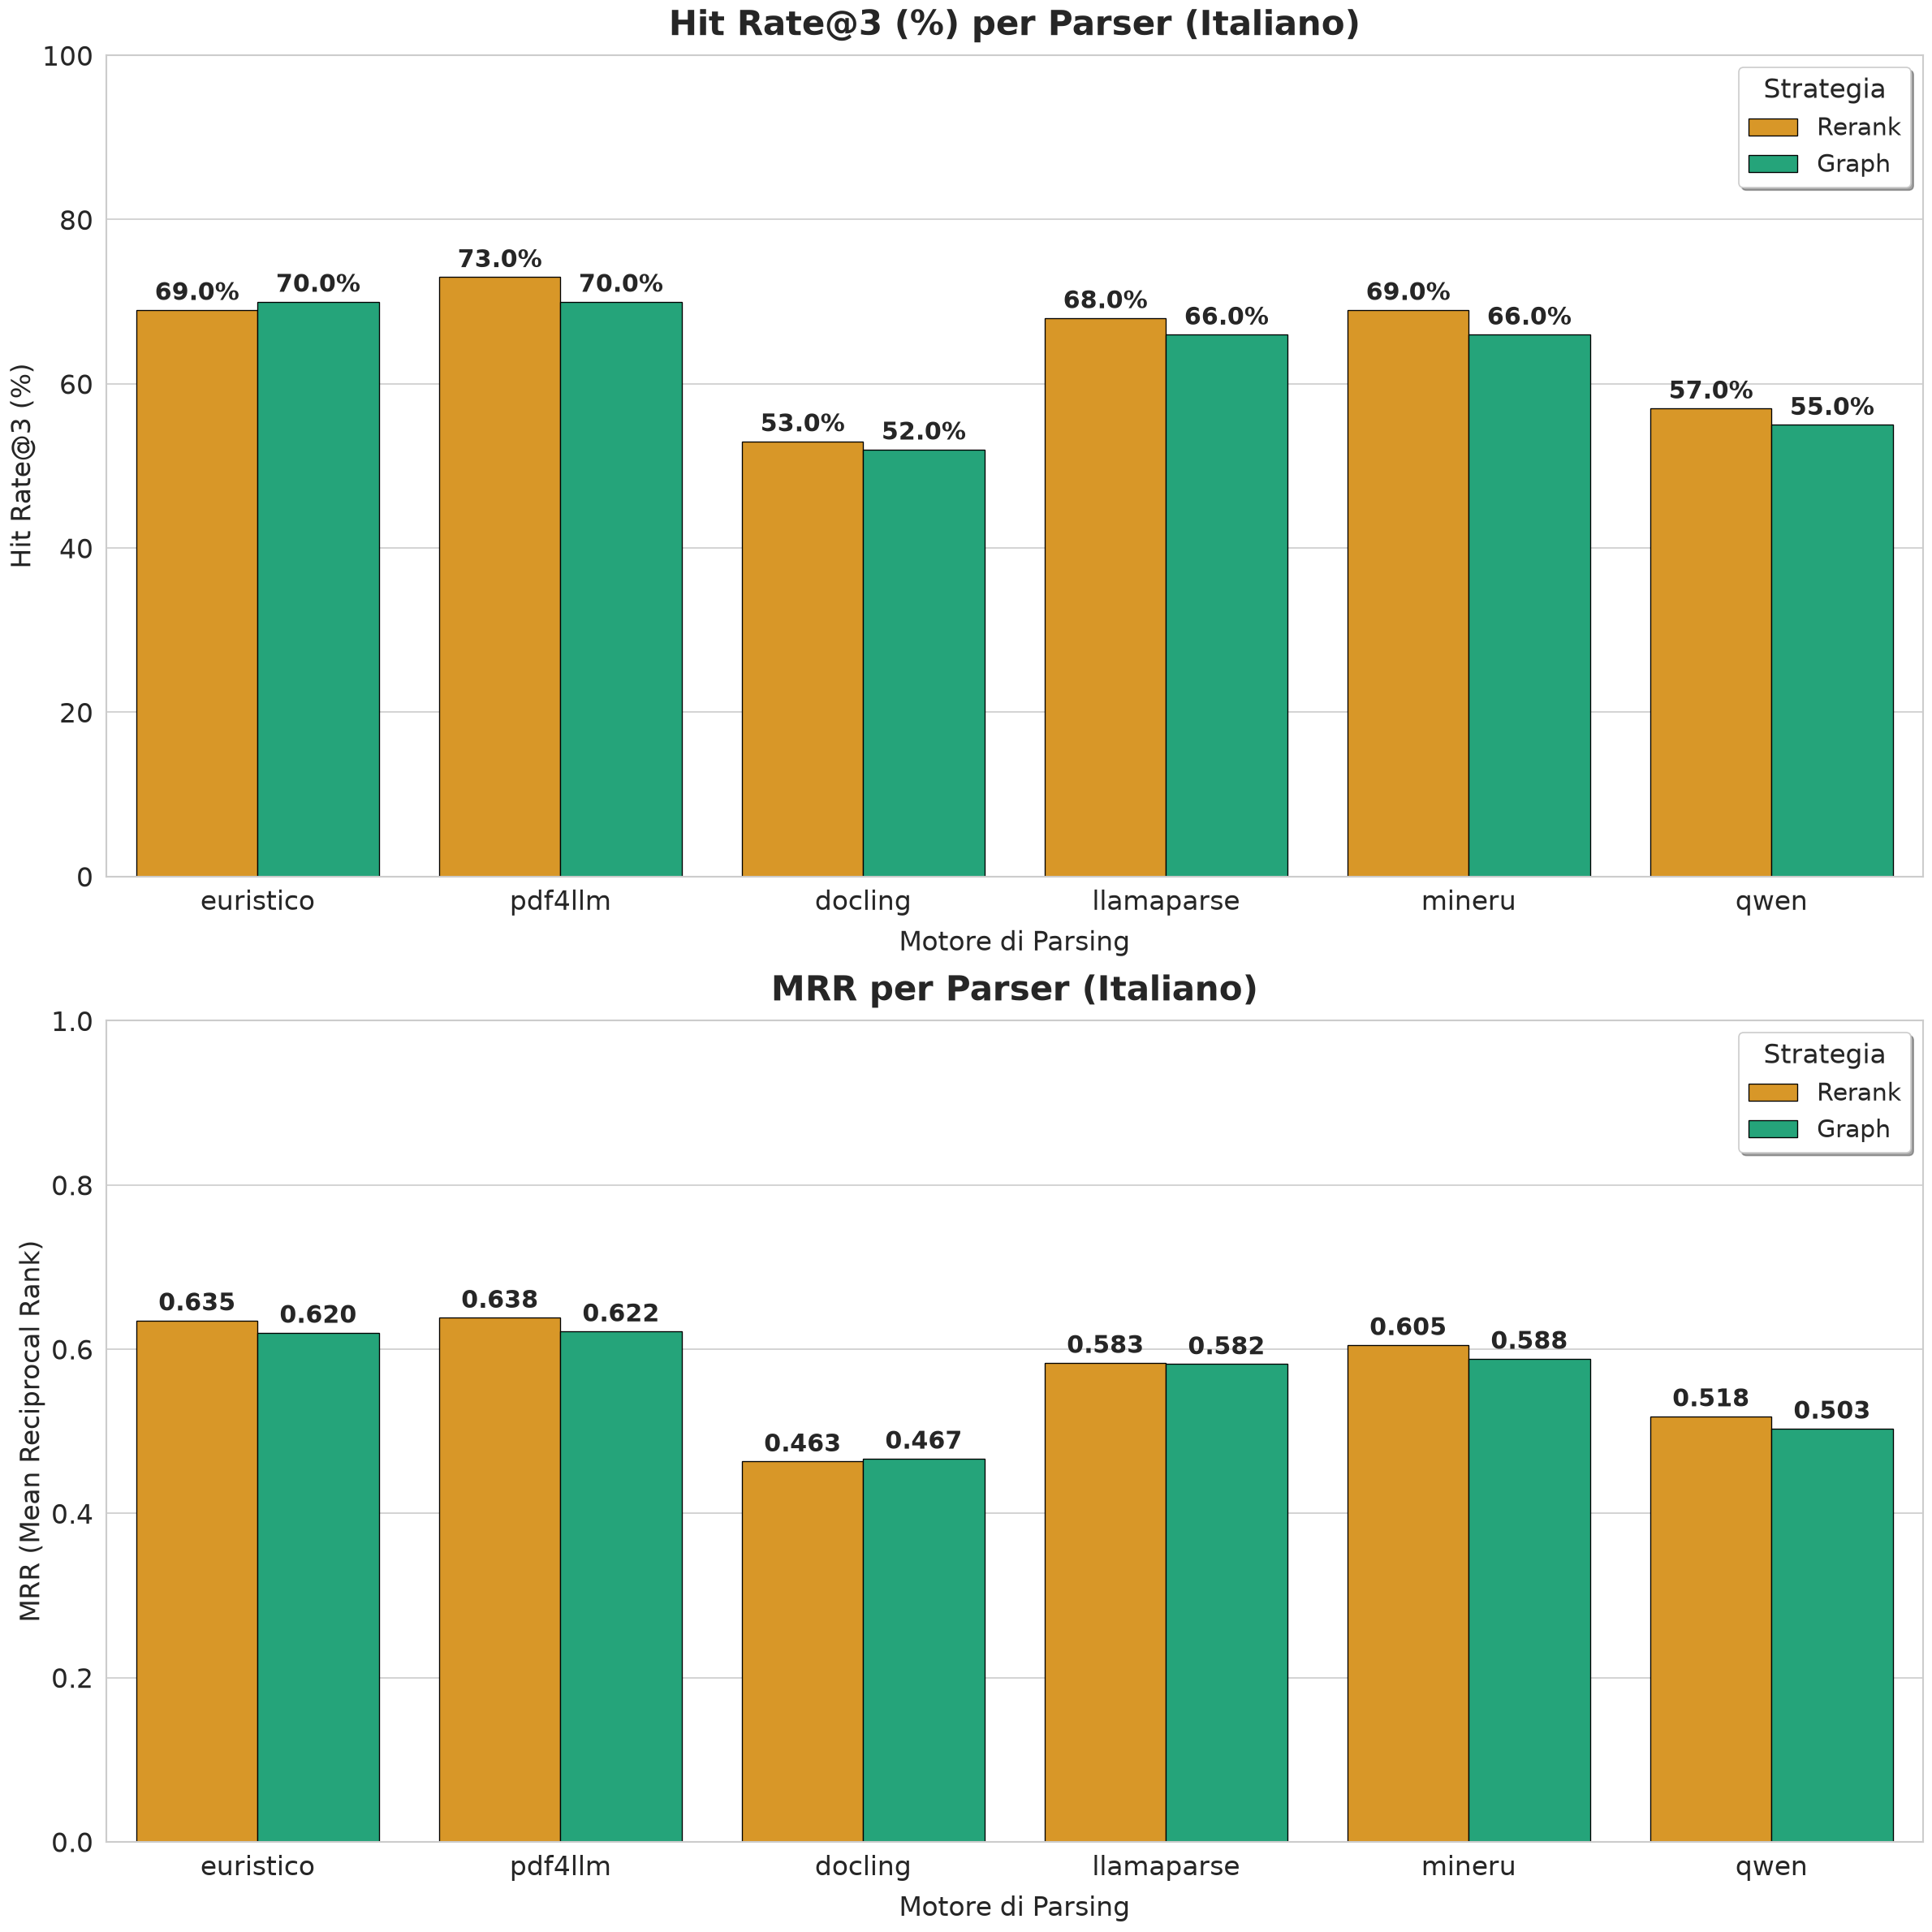

In [35]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE)

palette_strategies = {
    'Rerank': '#f59e0b', # Amber
    'Graph': '#10b981'  # Emerald
}

# 1. Hit Rate@3
sns.barplot(
    data=df_it,
    x='Parser',
    y='Hit Rate (%)',
    hue='Strategy',
    ax=axes[0],
    palette=palette_strategies,
    edgecolor='black',
    linewidth=0.8
)
axes[0].set_title('Hit Rate@3 (%) per Parser (Italiano)', fontsize=TITLE_FONTSIZE, fontweight='bold', pad=15)
axes[0].set_ylim(0, 100)
axes[0].set_xlabel('Motore di Parsing', fontsize=LABEL_FONTSIZE, labelpad=10)
axes[0].set_ylabel('Hit Rate@3 (%)', fontsize=LABEL_FONTSIZE)
axes[0].tick_params(axis='x', labelsize=LABEL_FONTSIZE)
axes[0].tick_params(axis='y', labelsize=LABEL_FONTSIZE)
axes[0].legend(title='Strategia', frameon=True, shadow=True, fontsize=LEGEND_FONTSIZE, title_fontsize=LEGEND_TITLE_FONTSIZE)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', padding=3, fontsize=BAR_FONTSIZE, fontweight='bold')

# 2. MRR
sns.barplot(
    data=df_it,
    x='Parser',
    y='MRR',
    hue='Strategy',
    ax=axes[1],
    palette=palette_strategies,
    edgecolor='black',
    linewidth=0.8
)
axes[1].set_title('MRR per Parser (Italiano)', fontsize=TITLE_FONTSIZE, fontweight='bold', pad=15)
axes[1].set_ylim(0, 1.0)
axes[1].set_xlabel('Motore di Parsing', fontsize=LABEL_FONTSIZE, labelpad=10)
axes[1].set_ylabel('MRR (Mean Reciprocal Rank)', fontsize=LABEL_FONTSIZE)
axes[1].tick_params(axis='x', labelsize=LABEL_FONTSIZE)
axes[1].tick_params(axis='y', labelsize=LABEL_FONTSIZE)
axes[1].legend(title='Strategia', frameon=True, shadow=True, fontsize=LEGEND_FONTSIZE, title_fontsize=LEGEND_TITLE_FONTSIZE)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.3f', padding=3, fontsize=BAR_FONTSIZE, fontweight='bold')

plt.tight_layout()
plt.savefig("../thesis_report/images/pdf/hit_rate_metodo_it.pdf", bbox_inches='tight')
plt.savefig("../thesis_report/images/png/hit_rate_metodo_it.png", bbox_inches='tight')
plt.show()

### Tempo Medio di Query Retrieval (Italiano)

Confrontiamo la latenza di retrieval misurata in secondi per ciascun parser e strategia.

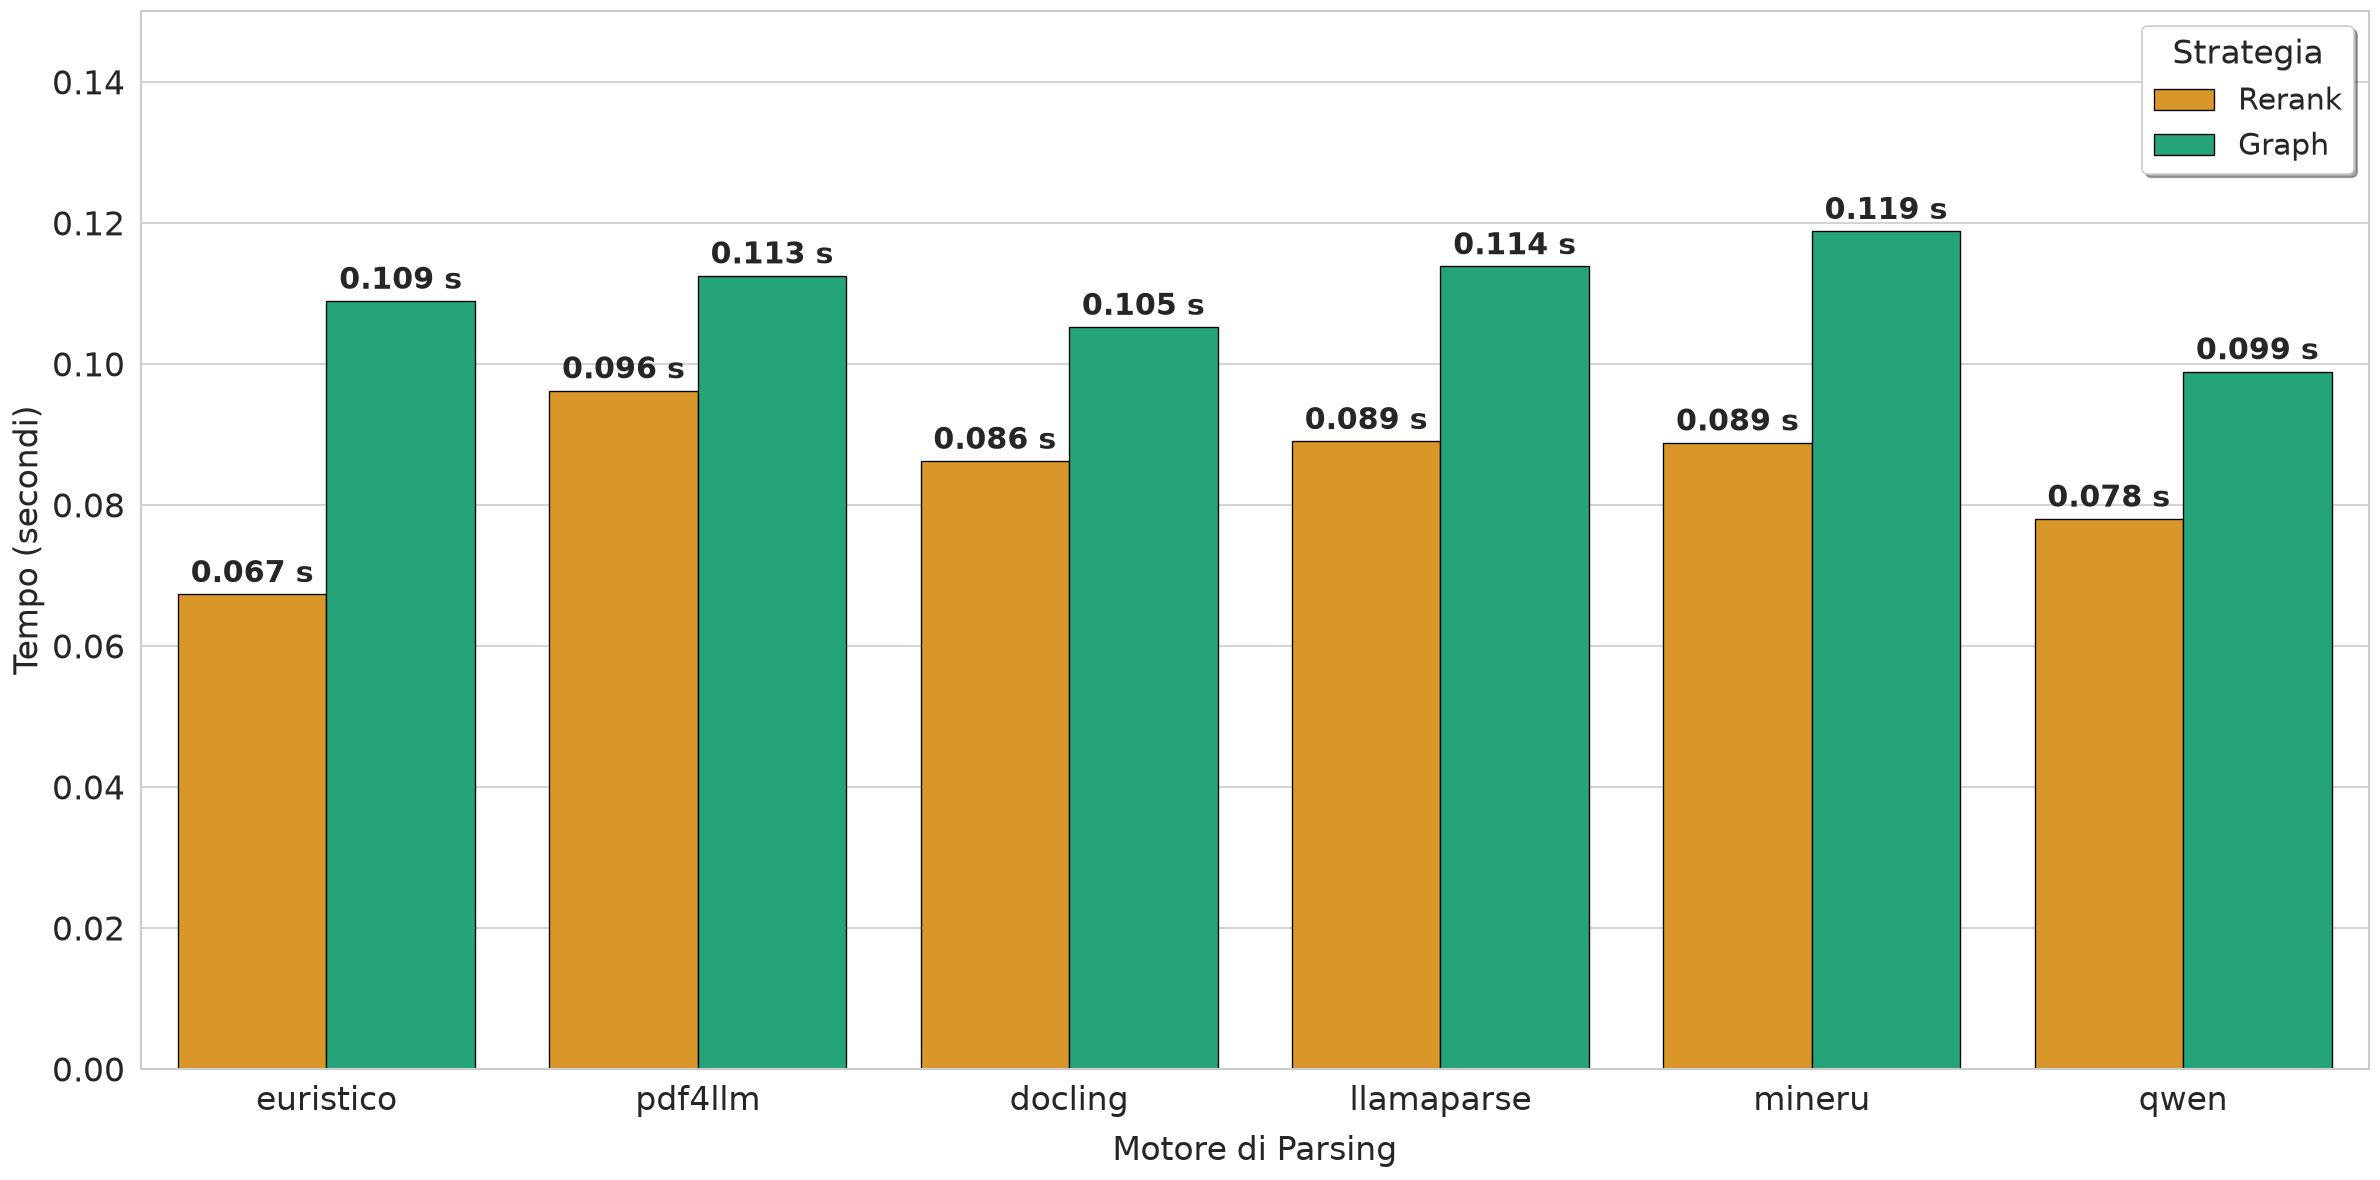

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

sns.barplot(
    data=df_it,
    x='Parser',
    y='Tempo Medio (s)',
    hue='Strategy',
    palette=palette_strategies,
    edgecolor='black',
    linewidth=0.8
)

# ax.set_title('Tempo Medio di Query Retrieval (secondi) - Italiano', fontsize=TITLE_FONTSIZE, fontweight='bold', pad=15)
ax.set_ylim(0, 0.15)
ax.set_xlabel('Motore di Parsing', fontsize=LABEL_FONTSIZE, labelpad=10)
ax.set_ylabel('Tempo (secondi)', fontsize=LABEL_FONTSIZE)
ax.tick_params(axis='x', labelsize=LABEL_FONTSIZE)
ax.tick_params(axis='y', labelsize=LABEL_FONTSIZE)
ax.legend(title='Strategia', frameon=True, shadow=True, fontsize=LEGEND_FONTSIZE, title_fontsize=LEGEND_TITLE_FONTSIZE)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f s', padding=3, fontsize=BAR_FONTSIZE, fontweight='bold')

plt.tight_layout()
plt.savefig("../thesis_report/images/pdf/tempo_medio_retrieval_metodi_it.pdf", bbox_inches='tight')
plt.savefig("../thesis_report/images/png/tempo_medio_retrieval_metodi_it.png", bbox_inches='tight')
plt.show()

## 2. Confronto delle 4 Strategie di Retrieval (Inglese)

Nel benchmark inglese (`english_benchmark`) andiamo a confrontare direttamente l'impatto di tutte e 4 le strategie disponibili (**Vector**, **Hybrid**, **Rerank**, **Graph**) su diversi database vettoriali/configurazioni.

Nota: rinominiamo il database `cloud_700` in `euristico_cloud_700` per coerenza con la baseline euristica in cloud.

In [6]:
en_records = []
for rec in benchmarks_data['english_benchmark']:
    db_name = rec['DB Name']
    readable_db = db_name.replace('chroma_', '')
    # Correzione del nome 'cloud_700' in 'euristico_cloud_700'
    if readable_db == 'cloud_700':
        readable_db = 'euristico_cloud_700'
    en_records.append({
        'Database': readable_db,
        'Strategy': rec['Strategia'],
        'Hit Rate (%)': rec['Hit Rate@3 (%)'],
        'Precision (%)': rec['Precision@3 (%)'],
        'Recall (%)': rec['Recall@3 (%)'],
        'MRR': rec['MRR'],
        'Tempo Medio (s)': rec['Tempo Medio (s)']
    })

df_en = pd.DataFrame(en_records)

# Ordine prestabilito per le Strategie
strategy_order = ['Vector', 'Hybrid', 'Rerank', 'Graph']
df_en['Strategy'] = pd.Categorical(df_en['Strategy'], categories=strategy_order, ordered=True)

# Ordine dei Database (con euristico_cloud_700)
db_order = ['euristico_locale_700', 'pdf4llm_locale_700', 'euristico_cloud_700', 'pdf4llm_cloud_700']
df_en['Database'] = pd.Categorical(df_en['Database'], categories=[d for d in db_order if d in df_en['Database'].unique()], ordered=True)

df_en = df_en.sort_values(['Database', 'Strategy'])
df_en

,Database,Strategy,Hit Rate (%),Precision (%),Recall (%),MRR,Tempo Medio (s)
8,euristico_locale_700,Vector,68.0,48.00,68.0,0.6067,0.0262
9,euristico_locale_700,Hybrid,73.0,34.00,73.0,0.6917,0.0304
10,euristico_locale_700,Rerank,78.0,37.33,78.0,0.7150,0.0644
11,euristico_locale_700,Graph,75.0,38.67,75.0,0.7100,0.1056
0,pdf4llm_locale_700,Vector,75.0,38.00,75.0,0.6667,0.0259
1,pdf4llm_locale_700,Hybrid,75.0,37.67,75.0,0.6833,0.0281
2,pdf4llm_locale_700,Rerank,79.0,41.33,79.0,0.7183,0.0944
3,pdf4llm_locale_700,Graph,78.0,41.33,78.0,0.7133,0.1110
12,euristico_cloud_700,Vector,68.0,36.67,68.0,0.6200,0.4680
13,euristico_cloud_700,Hybrid,68.0,36.67,68.0,0.6200,0.3293


### Grafici Comparativi per le Strategie (Inglese)

Mostriamo l'Hit Rate@3 e il valore MRR per ciascun database, raggruppando per le quattro strategie di retrieval.

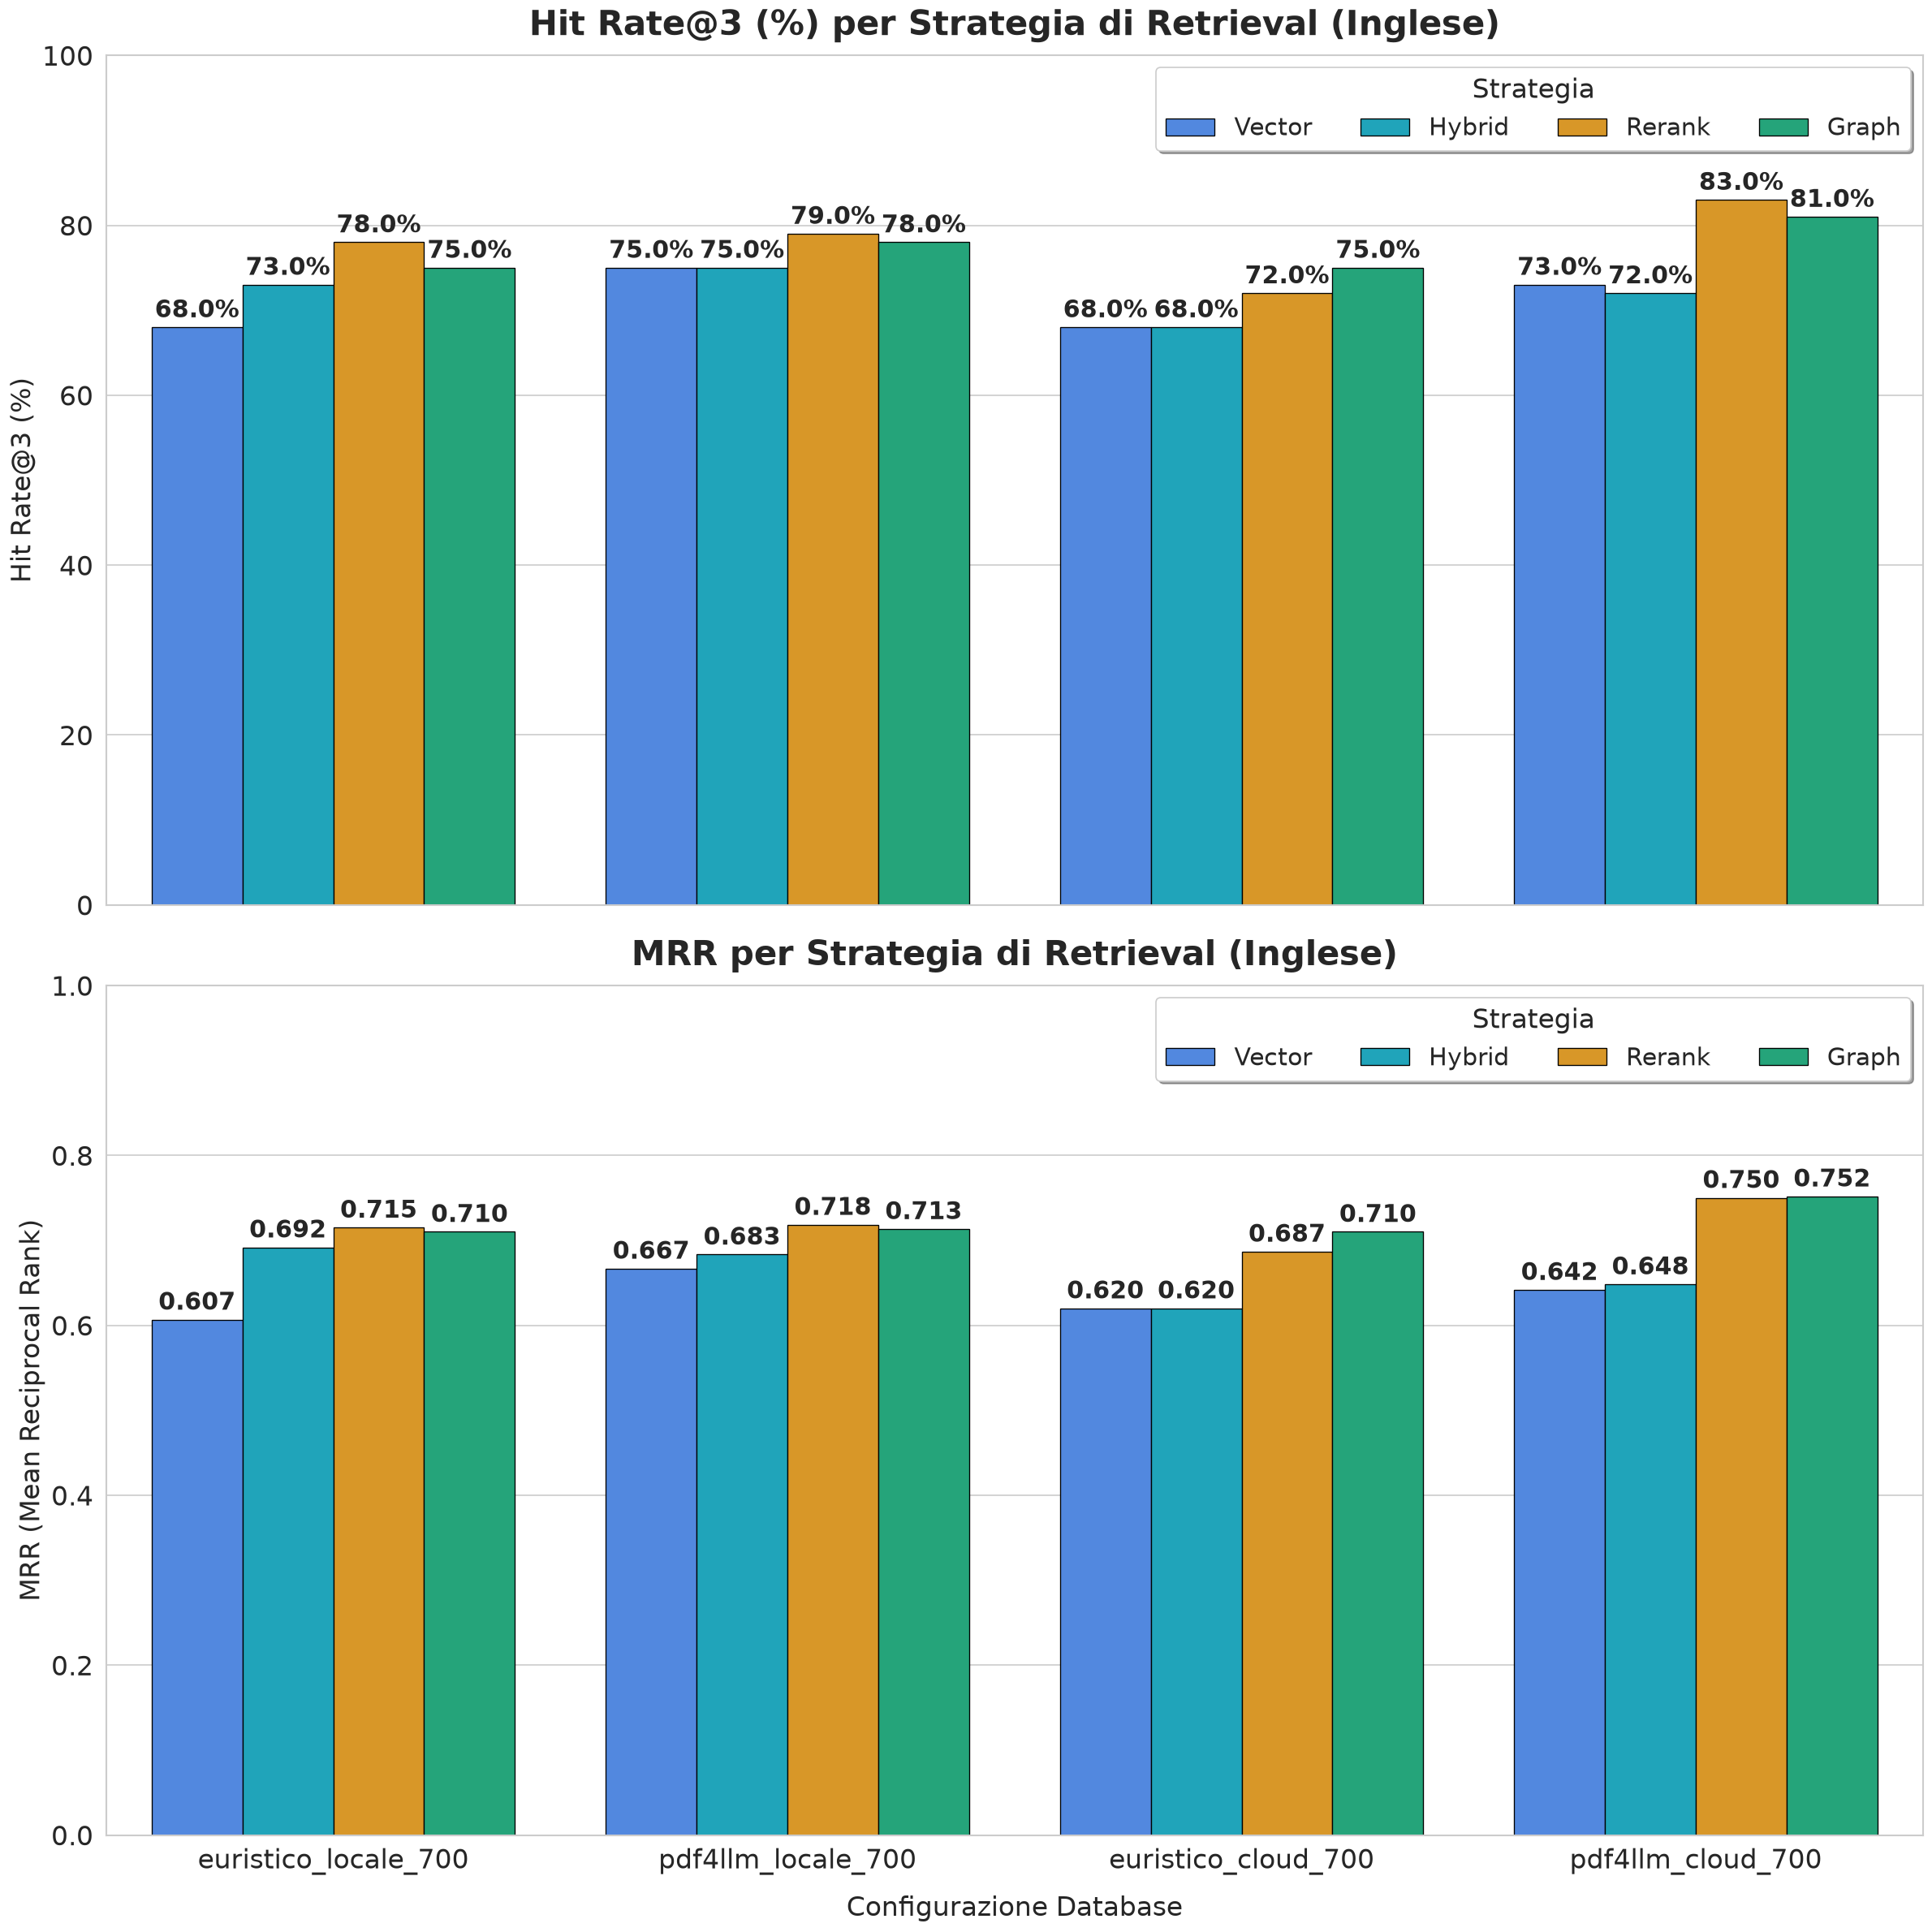

In [48]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE, sharex=True)

colors_strategies_4 = {
    'Vector': '#3b82f6',   # Blue
    'Hybrid': '#06b6d4',   # Cyan
    'Rerank': '#f59e0b',   # Amber
    'Graph': '#10b981'     # Emerald
}

# 1. Hit Rate@3
sns.barplot(
    data=df_en,
    x='Database',
    y='Hit Rate (%)',
    hue='Strategy',
    ax=axes[0],
    palette=colors_strategies_4,
    edgecolor='black',
    linewidth=0.8
)
axes[0].set_title('Hit Rate@3 (%) per Strategia di Retrieval (Inglese)', fontsize=TITLE_FONTSIZE, fontweight='bold', pad=15)
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('Hit Rate@3 (%)', fontsize=LABEL_FONTSIZE)
axes[0].set_xlabel('Configurazione Database', fontsize=LABEL_FONTSIZE, labelpad=15)
axes[0].tick_params(axis='x', labelsize=LABEL_FONTSIZE)
axes[0].tick_params(axis='y', labelsize=LABEL_FONTSIZE)
axes[0].legend(title='Strategia', frameon=True, shadow=True, fontsize=LEGEND_FONTSIZE, title_fontsize=LEGEND_TITLE_FONTSIZE, loc='upper right', ncol=4)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', padding=3, fontsize=BAR_FONTSIZE, fontweight='bold')

# 2. MRR
sns.barplot(
    data=df_en,
    x='Database',
    y='MRR',
    hue='Strategy',
    ax=axes[1],
    palette=colors_strategies_4,
    edgecolor='black',
    linewidth=0.8
)
axes[1].set_title('MRR per Strategia di Retrieval (Inglese)', fontsize=TITLE_FONTSIZE, fontweight='bold', pad=15)
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel('MRR (Mean Reciprocal Rank)', fontsize=LABEL_FONTSIZE)
axes[1].set_xlabel('Configurazione Database', fontsize=LABEL_FONTSIZE, labelpad=15)
axes[1].tick_params(axis='x', labelsize=LABEL_FONTSIZE)
axes[1].tick_params(axis='y', labelsize=LABEL_FONTSIZE)
axes[1].legend(title='Strategia', frameon=True, shadow=True, fontsize=LEGEND_FONTSIZE, title_fontsize=LEGEND_TITLE_FONTSIZE, loc='upper right', ncol=4)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.3f', padding=3, fontsize=BAR_FONTSIZE, fontweight='bold')

plt.tight_layout()
plt.savefig("../thesis_report/images/pdf/hit_rate_strategie_en.pdf", bbox_inches='tight')
plt.savefig("../thesis_report/images/png/hit_rate_strategie_en.png", bbox_inches='tight')
plt.show()

### Tempo di Risposta per Strategia (Inglese)

Valutiamo il tempo di query retrieval per le quattro strategie in lingua inglese.

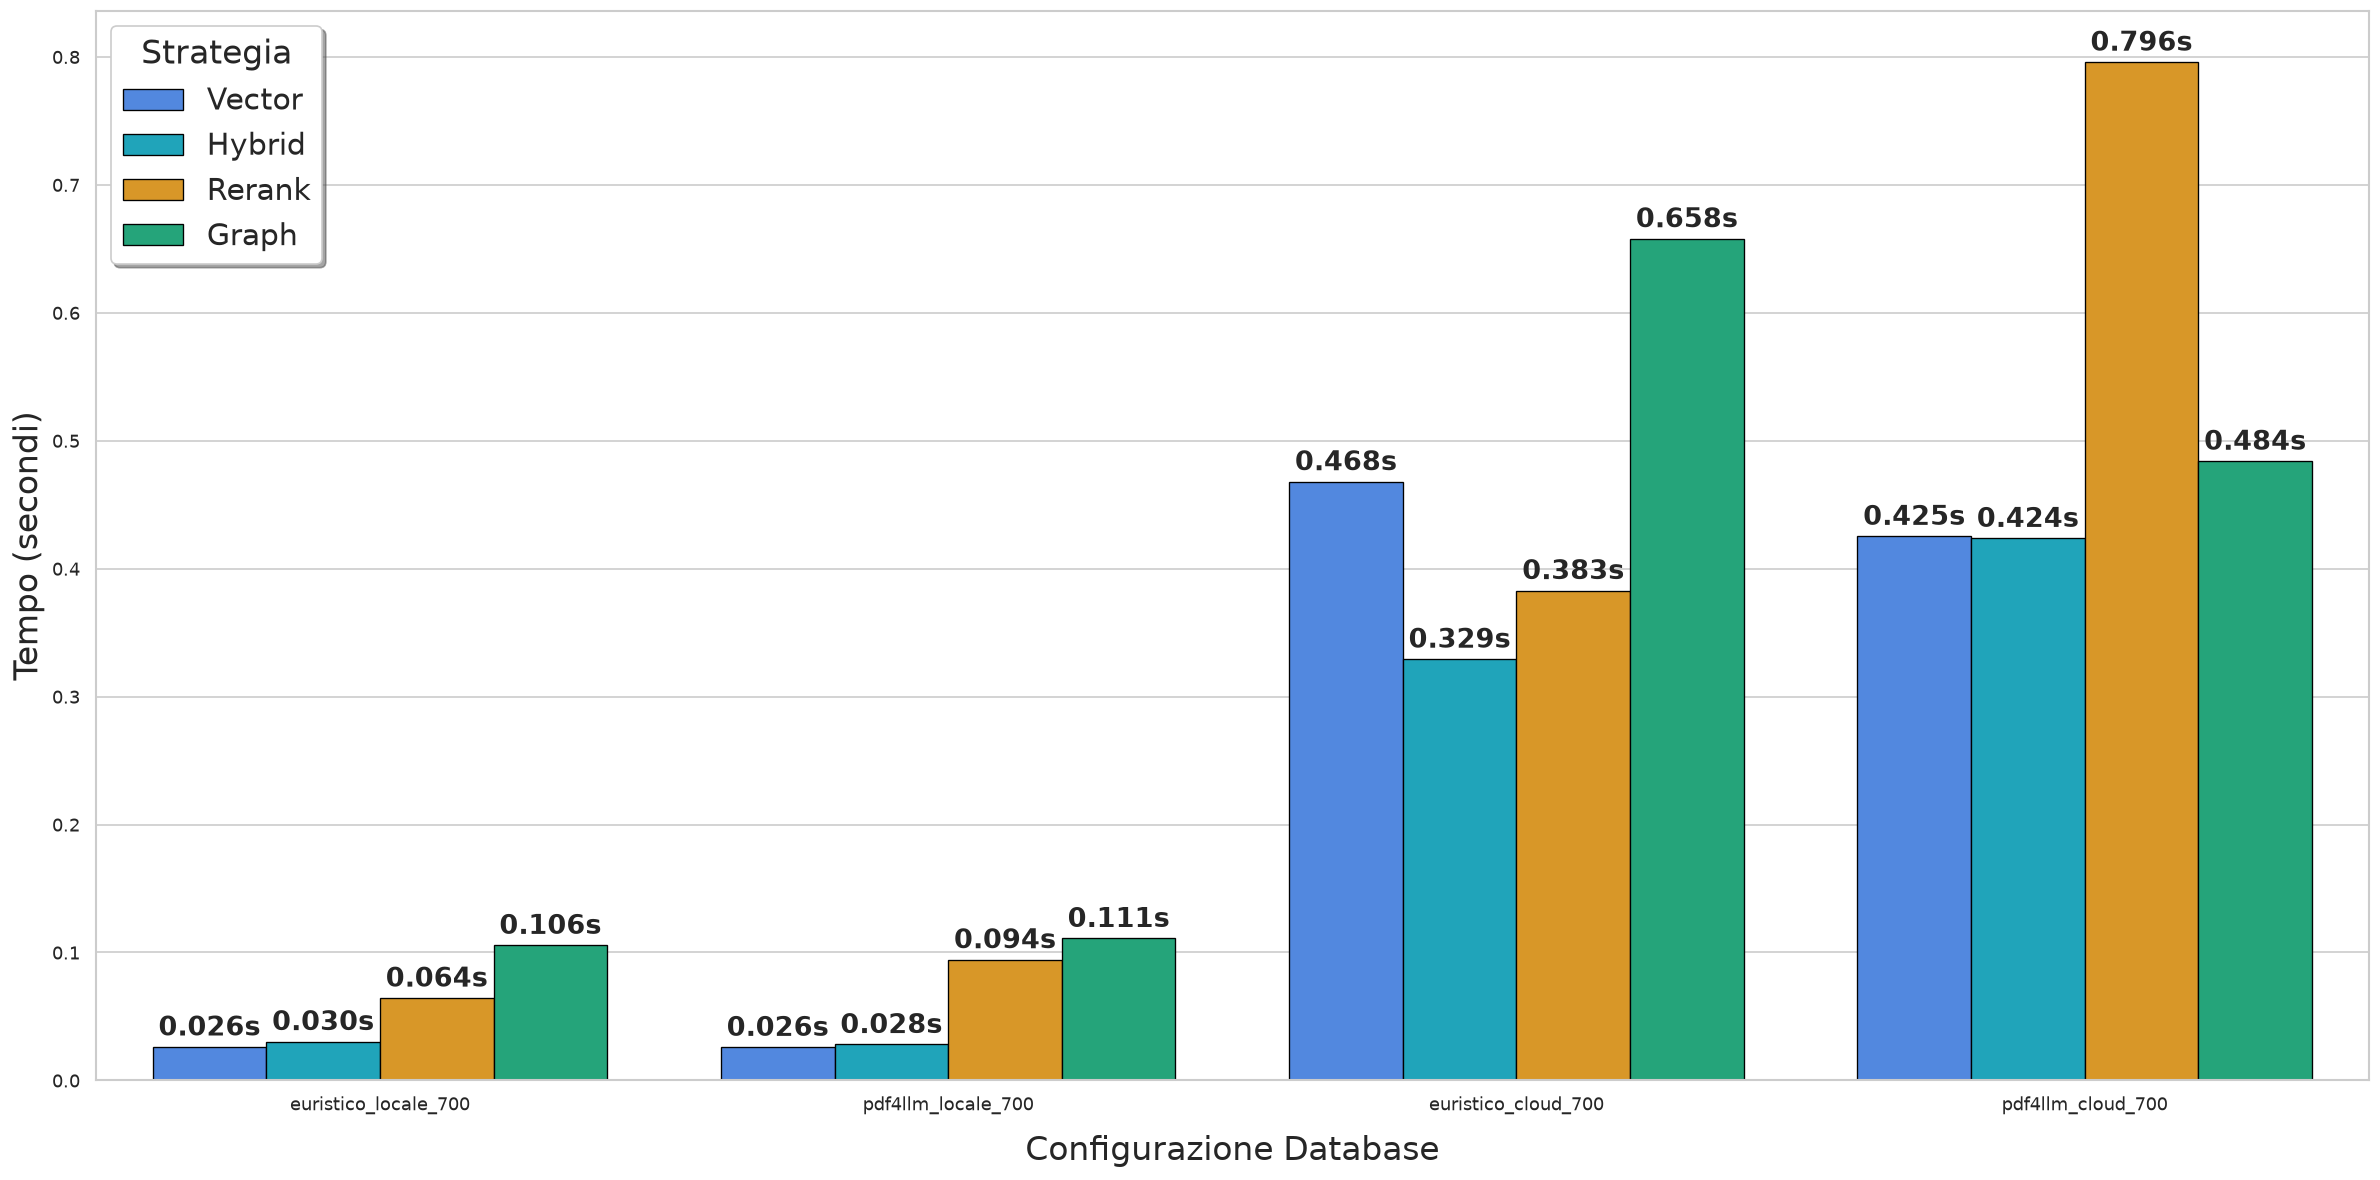

In [52]:
plt.figure(figsize=(20, 10))

sns.barplot(
    data=df_en,
    x='Database',
    y='Tempo Medio (s)',
    hue='Strategy',
    palette=colors_strategies_4,
    edgecolor='black',
    linewidth=0.8
)

# plt.title('Tempo Medio di Query Retrieval (secondi) - Inglese', fontsize=TITLE_FONTSIZE, fontweight='bold', pad=15)
plt.xlabel('Configurazione Database', fontsize=LABEL_FONTSIZE, labelpad=12)
plt.ylabel('Tempo (secondi)', fontsize=LABEL_FONTSIZE)
plt.legend(title='Strategia', frameon=True, shadow=True, fontsize=LEGEND_FONTSIZE, title_fontsize=LEGEND_TITLE_FONTSIZE)

ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%.3fs', padding=3, fontsize=BAR_FONTSIZE - 2, fontweight='bold')

plt.tight_layout()
plt.savefig("../thesis_report/images/pdf/tempo_medio_retrieval_en.pdf", bbox_inches='tight')
plt.savefig("../thesis_report/images/png/tempo_medio_retrieval_en.png", bbox_inches='tight')
plt.show()